# 10× Architecture Experiment — EfficientNet-B3 vs ResNet50

**Goal:** Find the best architecture for the 10× histology classifier using EfficientNet-B3 on a *subsampled* dataset.  
Patch size: **512**  
Models: `tf_efficientnet_b3 - ResNet50` (timm)

The experiment trains for a fixed number of quick epochs on a stratified patient-level subsample, then prints a comparison table so you can pick the winner before committing to a full run.

In [1]:
import torch
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0)) 

GPU name: NVIDIA GeForce RTX 4060 Ti


## Cell 1 — Imports & Configuration

In [2]:
# ── Standard library ─────────────────────────────────────────────────────────
from pathlib import Path
import hashlib, cv2, random, time, gc, json
cv2.setNumThreads(0)
from collections import Counter

# ── Scientific / ML ──────────────────────────────────────────────────────────
import numpy as np
from PIL import Image
from sklearn.metrics import fbeta_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast
from torch.utils.data import Dataset, DataLoader, Subset

import timm
from torchvision import transforms
from torchvision.transforms import InterpolationMode
import gc


# ── Pretty output ─────────────────────────────────────────────────────────────
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# ⚙️  CONFIGURATION  — edit these
# ─────────────────────────────────────────────────────────────────────────────
DATA_ROOT       = Path(r"G:/My Drive/CLPD-MF-Dataset")
PATCH_CACHE     = Path('./patch_cache_exp')   # modify this for 10x at 
SAVE_DIR        = Path('./exp_x10_models')

# Patch sizes to compare
PATCH_SIZES     = [512]

# Stride is half the patch size for each experiment
# (keeps overlap constant relative to patch size)
STRIDE_RATIO    = 0.5

# Subsample ratio — fraction of patches used (keeps experiments fast)
SUBSAMPLE_RATIO = 0.05      # 5% of the 20× patch dataset
SUBSAMPLE_SEED  = 42

EPOCHS          = 7         # quick sweep; raise to 10-15 for a more reliable signal
BATCH_SIZE      = 16
LR              = 3e-4
WEIGHT_DECAY    = 1e-4
DROPOUT         = 0.3
MAX_PATCHES     = 150       # per WSI image

MODEL_ARCH      = ['tf_efficientnet_b3', 'resnet50']

# Split seeds / fractions (mirror main notebook)
SPLIT_SEED      = 45
VAL_FRAC        = 0.15

DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Sanity checks ─────────────────────────────────────────────────────────────
assert DATA_ROOT.exists(), f"Dataset not found: {DATA_ROOT}"
PATCH_CACHE.mkdir(exist_ok=True)
SAVE_DIR.mkdir(exist_ok=True)

print(f"Device  : {DEVICE}")
print(f"Dataset : {DATA_ROOT}")
print(f"Patches to test: {PATCH_SIZES}")
print(f"Model   : {MODEL_ARCH}")

Device  : cuda
Dataset : G:\My Drive\CLPD-MF-Dataset
Patches to test: [512]
Model   : ['tf_efficientnet_b3', 'resnet50']


c:\Users\Mohamed Hazem\anaconda3\envs\dlclass\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cell 2 — Dataset Discovery

In [4]:
def list_images_and_labels(root):
    """
    Walk the CLPD-MF-Dataset folder and return a flat list of dicts:
        {path, label, patient, mag, subtype}
    Only x20 images are needed for this experiment, but we keep x10
    so the patient-level split mirrors the main notebook exactly.
    """
    rows = []
    root = Path(root)

    # ── MF ────────────────────────────────────────────────────────────────────
    mf_dir = root / "MF"
    if mf_dir.exists():
        for patient_dir in mf_dir.iterdir():
            if not patient_dir.is_dir():
                continue
            patient_name = patient_dir.name
            for mag in ['x10', 'x20']:
                mag_dir = patient_dir / mag
                if mag_dir.exists():
                    for img_path in mag_dir.glob('*.tif'):
                        rows.append(dict(path=img_path, label='MF',
                                         patient=patient_name, mag=mag, subtype=None))

    # ── Non-MF ────────────────────────────────────────────────────────────────
    nonmf_dir = root / "Non-MF"
    if nonmf_dir.exists():
        for subtype_dir in nonmf_dir.iterdir():
            if not subtype_dir.is_dir():
                continue
            subtype = subtype_dir.name
            for patient_dir in subtype_dir.iterdir():
                if not patient_dir.is_dir():
                    continue
                patient_name = patient_dir.name
                for mag in ['x10', 'x20']:
                    mag_dir = patient_dir / mag
                    if mag_dir.exists():
                        for img_path in mag_dir.glob('*.tif'):
                            rows.append(dict(path=img_path, label='Non-MF',
                                             patient=patient_name, mag=mag,
                                             subtype=subtype))
    return rows


all_images = list_images_and_labels(DATA_ROOT)
x10_images = [r for r in all_images if r['mag'] == 'x10']

print(f"Total images  : {len(all_images)}")
print(f"10× images    : {len(x10_images)}")
label_counts = Counter(r['label'] for r in x10_images)
for lbl, cnt in label_counts.items():
    pts = len(set(r['patient'] for r in x10_images if r['label'] == lbl))
    print(f"  {lbl}: {cnt} images | {pts} patients")

Total images  : 5765
10× images    : 1981
  MF: 1265 images | 266 patients
  Non-MF: 716 images | 152 patients


## Cell 3 — Patient-Level Split  
Identical logic to the main notebook so results are directly comparable.

In [5]:
def patient_split_stratified(rows, mag=None, val_frac=0.15, seed=45):
    cls_map = {}
    for r in rows:
        if mag is not None and r['mag'] != mag:
            continue
        cls_map.setdefault(r['label'], {}).setdefault(r['patient'], []).append(r)

    train_rows, val_rows = [], []
    rng = random.Random(seed)
    for cls, patients_dict in cls_map.items():
        patients = list(patients_dict.keys())
        rng.shuffle(patients)
        n_val = max(1, int(len(patients) * val_frac))
        val_p = set(patients[:n_val])
        for p, rlist in patients_dict.items():
            (val_rows if p in val_p else train_rows).extend(rlist)
    return train_rows, val_rows


# Three-way split: 70 / 15 / 15  (patient level, same seeds as main notebook)
train_val_rows, test_rows = patient_split_stratified(all_images, mag=None,
                                                      val_frac=VAL_FRAC, seed=SPLIT_SEED)
adjusted_val_frac = VAL_FRAC / (1 - VAL_FRAC)
train_rows, val_rows = patient_split_stratified(train_val_rows, mag=None,
                                                 val_frac=adjusted_val_frac, seed=SPLIT_SEED)

# Filter to 10x only
train_rows_10 = [r for r in train_rows if r['mag'] == 'x10']
val_rows_10   = [r for r in val_rows   if r['mag'] == 'x10']
test_rows_10  = [r for r in test_rows  if r['mag'] == 'x10']

print("10× image rows  | train:", len(train_rows_10),
      "| val:", len(val_rows_10), "| test:", len(test_rows_10))
print("Patient counts  | train:",
      len(set(r['patient'] for r in train_rows_10)),
      "| val:", len(set(r['patient'] for r in val_rows_10)),
      "| test:", len(set(r['patient'] for r in test_rows_10)))

10× image rows  | train: 1397 | val: 316 | test: 268
Patient counts  | train: 296 | val: 62 | test: 60


## Cell 4 — Patch Extraction & Cache

In [6]:
def extract_and_cache_patches(
    img_path,
    patch_size=512,
    stride=256,
    min_foreground_ratio=0.285,
    max_patches_per_image=150,
):
    """
    Extract tissue patches from a WSI.  Results are cached under
    PATCH_CACHE / <sha1> / ps<patch_size> / so that different
    patch sizes share the same top-level folder but are kept separate.
    """
    key       = hashlib.sha1(str(img_path).encode()).hexdigest()
    cache_dir = PATCH_CACHE / key / f"ps{patch_size}"

    if cache_dir.exists() and any(cache_dir.iterdir()):
        return sorted(str(p) for p in cache_dir.glob('*.jpg'))

    cache_dir.mkdir(parents=True, exist_ok=True)
    patches = []

    # CRITICAL FIX: Use 'with' so Windows forcefully closes the file handle immediately
    with Image.open(img_path) as img:
        W, H  = img.size

        for y in range(0, H - patch_size + 1, stride):
            for x in range(0, W - patch_size + 1, stride):
                # CRITICAL FIX: Crop FIRST, then convert only the tiny patch to RGB
                crop = img.crop((x, y, x + patch_size, y + patch_size))
                crop_rgb = crop.convert('RGB')
                
                arr  = np.asarray(crop_rgb)
                hsv  = cv2.cvtColor(arr, cv2.COLOR_RGB2HSV)
                
                if (hsv[:, :, 1] > 20).mean() < min_foreground_ratio:
                    continue
                
                fname = cache_dir / f"{x}_{y}.jpg"
                crop_rgb.save(fname, quality=90)
                patches.append(str(fname))
                
                if len(patches) >= max_patches_per_image:
                    break
            if len(patches) >= max_patches_per_image:
                break

    gc.collect()
    return patches

In [7]:
import concurrent.futures
from PIL import Image
from torch.utils.data import Dataset

# ── 1. The Isolated Worker Function ──────────────────────────────────────────
# This must be a top-level function so Windows can pickle it for multiple cores.
def process_single_image(args):
    row, patch_size, max_patches, stride_ratio = args
    
    path  = row['path'] if isinstance(row, dict) else row.path
    label = row['label'] if isinstance(row, dict) else row.label
    stride = int(patch_size * stride_ratio)
    
    try:
        # Call your existing function (it handles the cache directory logic)
        patches = extract_and_cache_patches(
            path,
            patch_size=patch_size,
            stride=stride,
            max_patches_per_image=max_patches,
        )
        
        # Return a lightweight list of dictionaries
        return [{'img': p, 'label': label, 'source': str(path)} for p in patches]
        
    except Exception as e:
        print(f"Error processing {path}: {e}")
        return []

# ── 2. The Orchestrator ──────────────────────────────────────────────────────
def precompute_patches_multicore(rows, patch_sizes, max_patches, stride_ratio):
    print("🚀 Starting Multi-Core Offline Patch Extraction 🚀")
    
    # We will return a dictionary: { 256: [patch_list], 384: [patch_list], ... }
    master_dict = {ps: [] for ps in patch_sizes}
    
    for ps in patch_sizes:
        print(f"\n--- Extracting for Patch Size: {ps} ---")
        tasks = [(r, ps, max_patches, stride_ratio) for r in rows]
        
        # max_workers=4 is usually safe. If your PC lags, drop to 2.
        # Switch to ThreadPoolExecutor and lower max_workers to 2 to protect your RAM
        with concurrent.futures.ThreadPoolExecutor(max_workers=2) as executor:            # Map the tasks to the cores
            results = executor.map(process_single_image, tasks)
            
            for i, result_batch in enumerate(results):
                master_dict[ps].extend(result_batch)
                if (i + 1) % 10 == 0:
                    print(f"  -> Processed {i + 1}/{len(rows)} WSI images...", end="\r")
                    
        print(f"\n  ✓ Size {ps} complete. Extracted {len(master_dict[ps])} total patches.")
        
    return master_dict

# ── 3. The Ultra-Fast Dataset Class ──────────────────────────────────────────
class MFHistologyDatasetFast(Dataset):
    def __init__(self, patch_list, mode='train', transform=None):
        self.items = patch_list
        self.transform = transform
        
        # Create a consistent label to index mapping dynamically
        labels_sorted = sorted({item['label'] for item in self.items})
        self.label2idx = {lab: i for i, lab in enumerate(labels_sorted)}

        if not self.items:
            print(f"[Warning] Dataset is empty (mode={mode})")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        it = self.items[idx]
        img = Image.open(it['img']).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
            
        return img, self.label2idx[it['label']], it['source']

## Cell 5 — Dataset Class

In [8]:
class MFHistologyDataset(Dataset):
    def __init__(
        self,
        rows,
        patch_size=512,
        mode='train',
        transform=None,
        max_patches_per_image=150,
    ):
        stride = int(patch_size * STRIDE_RATIO)
        # Ensure r is accessed correctly depending on if it's a dict or object
        labels_sorted = sorted({r['label'] if isinstance(r, dict) else r.label for r in rows})
        self.label2idx = {lab: i for i, lab in enumerate(labels_sorted)}
        self.transform  = transform
        self.items      = []

        for i, r in enumerate(rows):
            print(f"  -> Extracting from image {i+1}/{len(rows)}...", end="\r")
            # Extract path and label safely
            path = r['path'] if isinstance(r, dict) else r.path
            label = r['label'] if isinstance(r, dict) else r.label

            patches = extract_and_cache_patches(
                path,
                patch_size=patch_size,
                stride=stride,
                max_patches_per_image=max_patches_per_image,
            )
            
            for p in patches:
                self.items.append({
                    'img'   : p,
                    'label' : self.label2idx[label],
                    'source': str(path),
                })
            
            # ---------------------------------------------------------
            # THE CRITICAL MEMORY FIX
            # ---------------------------------------------------------
            # Delete the local reference to patches to free it up
            del patches 
            
            # Force the Garbage Collector to run every 10 images.
            # Doing it every single image is too slow; every 10 keeps RAM perfectly stable.
            # if i % 10 == 0:
            gc.collect()
            # ---------------------------------------------------------

        if not self.items:
            print(f"[Warning] Dataset is empty (mode={mode}, patch_size={patch_size})")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        it  = self.items[idx]
        img = Image.open(it['img']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, it['label'], it['source']


def make_transforms(patch_size: int):
    """Return (train_tf, val_tf) tuples for a given patch size."""
    # EfficientNet-B3 native input: 300×300.
    # We resize each crop to the model's native size so comparisons
    # are fair regardless of the patch_size used on disk.
    MODEL_INPUT = 300

    train_tf = transforms.Compose([
        transforms.Resize((MODEL_INPUT, MODEL_INPUT),
                          interpolation=InterpolationMode.BILINEAR),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]),
    ])

    val_tf = transforms.Compose([
        transforms.Resize((MODEL_INPUT, MODEL_INPUT),
                          interpolation=InterpolationMode.BILINEAR),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]),
    ])

    return train_tf, val_tf

## Cell 6 — Helper Functions

In [9]:
def compute_f2(preds, labels):
    if len(preds) == 0:
        return 0.0
    return fbeta_score(labels.numpy(), preds.numpy(), beta=2, zero_division=0)


def get_class_weights(dataset: MFHistologyDataset, device):
    counts = Counter(it['label'] for it in dataset.items)
    total  = sum(counts.values())
    w      = [total / counts.get(i, 1) for i in range(2)]
    return torch.tensor(w, dtype=torch.float).to(device)


def subsample_dataset(dataset, ratio=0.25, seed=42):
    n      = len(dataset)
    k      = max(1, int(n * ratio))
    g      = torch.Generator().manual_seed(seed)
    idx    = torch.randperm(n, generator=g)[:k].tolist()
    return Subset(dataset, idx)


def create_model(arch, num_classes=2, dropout=DROPOUT):
    return timm.create_model(
        arch, pretrained=True, num_classes=num_classes, drop_rate=dropout
    )


# ── Training helpers ──────────────────────────────────────────────────────────
def train_one_epoch_accum(model, loader, optimizer, criterion, scaler, accum_steps):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    optimizer.zero_grad() # Move zero_grad to the start!
    
    for batch_idx, (imgs, labels, _) in enumerate(loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        
        with autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, labels)
            # Normalize the loss based on accumulation steps
            loss = loss / accum_steps 
            
        scaler.scale(loss).backward()
        
        # Only step the optimizer after accumulating enough gradients
        if ((batch_idx + 1) % accum_steps == 0) or (batch_idx + 1 == len(loader)):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            
        # Keep tracking metrics normally (un-normalize the loss for logging)
        total_loss += (loss.item() * accum_steps) * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
        
    return total_loss / total, correct / total


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out   = model(imgs)
            loss  = criterion(out, labels)
            preds = out.argmax(1)
            total_loss += loss.item() * imgs.size(0)
            correct    += (preds == labels).sum().item()
            total      += imgs.size(0)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    avg_loss = total_loss / total if total > 0 else 0.0
    acc      = correct  / total if total > 0 else 0.0
    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    f2 = compute_f2(all_preds, all_labels)
    return avg_loss, acc, f2

## Cell 7 — Pre-cache All Patch Sizes  
Run this once to populate the disk cache before the experiment loop.
Skipping a patch size here means it will be cached on-demand during training (slower).

In [10]:
# The specific patch sizes needed for the competition
COMPETITION_SIZES = [512]

# Bump this up to 20% for the competition
CACHE_SAMPLE_RATIO = 0.5
rng_cache = random.Random(SUBSAMPLE_SEED)

def sample_rows(rows, ratio):
    sampled = []
    for label in ['MF', 'Non-MF']:
        label_rows = [r for r in rows if r['label'] == label]
        k = max(1, int(len(label_rows) * ratio))
        sampled += rng_cache.sample(label_rows, k)
    return sampled

print(f"🏆 PREPPING THE ARENA: Pre-caching patches using {CACHE_SAMPLE_RATIO*100:.0f}% of images...")

sampled_train = sample_rows(train_rows_10, CACHE_SAMPLE_RATIO)
sampled_val   = sample_rows(val_rows_10, CACHE_SAMPLE_RATIO)

# Run the multiprocessing extractor! 
# Warning: 1024 patches will take a bit longer to extract, but the threading will keep RAM safe.
train_patch_cache = precompute_patches_multicore(sampled_train, COMPETITION_SIZES, MAX_PATCHES, STRIDE_RATIO)
val_patch_cache   = precompute_patches_multicore(sampled_val, COMPETITION_SIZES, MAX_PATCHES, STRIDE_RATIO)

print("\n🎉 COMPETITION DATA PREPPED 🎉")

🏆 PREPPING THE ARENA: Pre-caching patches using 50% of images...
🚀 Starting Multi-Core Offline Patch Extraction 🚀

--- Extracting for Patch Size: 512 ---
  -> Processed 690/698 WSI images...
  ✓ Size 512 complete. Extracted 33415 total patches.
🚀 Starting Multi-Core Offline Patch Extraction 🚀

--- Extracting for Patch Size: 512 ---
  -> Processed 150/157 WSI images...
  ✓ Size 512 complete. Extracted 7541 total patches.

🎉 COMPETITION DATA PREPPED 🎉


## Cell 8 — Main Experiment Loop

For each patch size:
1. Build train / val datasets and subsample them.
2. Train `tf_efficientnet_b3` for `EPOCHS` epochs.
3. Record best-val-F2, best-val-Acc per size.

> **Tip:** Set `SUBSAMPLE_RATIO = 1.0` and `EPOCHS = 15` for a full comparison once you've narrowed the field.

In [11]:
# Define the exact match-ups you requested
COMPETITORS = [
    ('resnet50', 512),
    ('tf_efficientnet_b3', 512)
]

results = []

for arch, patch_size in COMPETITORS:
    print("\n" + "🔥"*35)
    print(f" COMPETITOR: {arch} | PATCH SIZE: {patch_size}")
    print("🔥"*35)

    train_tf, val_tf = make_transforms(patch_size)

    print("  Loading pre-computed datasets...")
    current_train_patches = train_patch_cache[patch_size]
    current_val_patches   = val_patch_cache[patch_size]
    
    train_ds = MFHistologyDatasetFast(current_train_patches, mode='train', transform=train_tf)
    val_ds   = MFHistologyDatasetFast(current_val_patches,   mode='val',   transform=val_tf)

    print(f"  Total Patches — train: {len(train_ds)}  val: {len(val_ds)}")

    # ---------------------------------------------------------
    # DYNAMIC VRAM SURVIVAL & ACCUMULATION MATH
    # Target Effective Batch Size = 16 for everyone
    # ---------------------------------------------------------
    if patch_size == 1024 and arch == 'tf_efficientnet_b3':
        safe_batch_size = 2
        accum_steps = 8
    elif patch_size == 1024 and arch == 'resnet50':
        safe_batch_size = 4
        accum_steps = 4
    elif patch_size == 640 and arch == 'tf_efficientnet_b3':
        safe_batch_size = 8
        accum_steps = 2
    else: # resnet50 @ 640
        safe_batch_size = 16
        accum_steps = 1

    print(f"  -> Physical Batch Size: {safe_batch_size} | Accumulation Steps: {accum_steps} | Effective Batch: 16")
    # ---------------------------------------------------------

    train_loader = DataLoader(train_ds, batch_size=safe_batch_size,
                              shuffle=True,  num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=safe_batch_size,
                              shuffle=False, num_workers=0, pin_memory=True)

    model     = create_model(arch=arch).to(DEVICE)        
    
    counts    = Counter(it['label'] for it in train_ds.items)
    total     = sum(counts.values())
    w         = [total / counts.get(lab, 1) for lab in train_ds.label2idx.keys()]
    weights   = torch.tensor(w, dtype=torch.float).to(DEVICE)
    
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scaler    = torch.amp.GradScaler('cuda')

    best_val_f2  = 0.0
    best_val_acc = 0.0

    for epoch in range(EPOCHS):
        t0 = time.time()
        # USE THE NEW ACCUMULATION TRAINING FUNCTION
        tr_loss, tr_acc           = train_one_epoch_accum(model, train_loader, optimizer, criterion, scaler, accum_steps)
        val_loss, val_acc, val_f2 = validate(model, val_loader, criterion)
        elapsed = time.time() - t0

        marker = ''
        if val_f2 > best_val_f2:
            best_val_f2  = val_f2
            best_val_acc = val_acc
            ckpt_path = SAVE_DIR / f"{arch}_ps{patch_size}_final_comp.pth"
            torch.save(model.state_dict(), ckpt_path)
            marker = '  ✓ saved'

        print(f"  Epoch {epoch+1}/{EPOCHS}  "
              f"tr_acc={tr_acc:.4f}  "
              f"val_acc={val_acc:.4f}  val_f2={val_f2:.4f}  "
              f"{elapsed:.1f}s{marker}")

    # ─── APPEND RESULTS TO LIST ─────────────────────────────────────────────
    results.append({
        'arch': arch,
        'patch_size': patch_size,
        'stride': int(patch_size * STRIDE_RATIO),
        'n_train_patches': len(train_ds),
        'n_val_patches': len(val_ds),
        'best_val_acc': best_val_acc,
        'best_val_f2': best_val_f2,
    })

    del model, optimizer, criterion, scaler, train_ds, val_ds
    del train_loader, val_loader
    torch.cuda.empty_cache()
    gc.collect()

print("\n" + "="*70)
print("FINAL COMPETITION COMPLETE")
print("="*70)


🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
 COMPETITOR: resnet50 | PATCH SIZE: 512
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
  Loading pre-computed datasets...
  Total Patches — train: 33415  val: 7541
  -> Physical Batch Size: 16 | Accumulation Steps: 1 | Effective Batch: 16
  Epoch 1/7  tr_acc=0.7144  val_acc=0.6504  val_f2=0.6274  653.2s  ✓ saved
  Epoch 2/7  tr_acc=0.8014  val_acc=0.6845  val_f2=0.5358  442.8s
  Epoch 3/7  tr_acc=0.8432  val_acc=0.6697  val_f2=0.3995  475.0s
  Epoch 4/7  tr_acc=0.8671  val_acc=0.6589  val_f2=0.5355  457.4s
  Epoch 5/7  tr_acc=0.8910  val_acc=0.6197  val_f2=0.4702  493.6s
  Epoch 6/7  tr_acc=0.9118  val_acc=0.6686  val_f2=0.3675  486.3s
  Epoch 7/7  tr_acc=0.9218  val_acc=0.6756  val_f2=0.4550  476.8s

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
 COMPETITOR: tf_efficientnet_b3 | PATCH SIZE: 512
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
  Loading pre-computed datasets...
  Total Patches — train: 33415  val: 7541
  -> Physical Batch Size: 16 | Accumulation Steps: 1 | Effective

## Cell 9 — Results Summary

In [12]:
summary = pd.DataFrame([
    {
        'Arch'         : r['arch'],
        'Patch Size' : r['patch_size'],
        'Stride'     : r['stride'],
        'Train Patches': r['n_train_patches'],
        'Val Patches'  : r['n_val_patches'],
        'Best Val Acc' : r['best_val_acc'],
        'Best Val F2'  : r['best_val_f2'],
    }
    for r in results
])
 
# Highlight best row per metric
def highlight_max(s):
    return ['background-color: #d4edda' if v == s.max() else '' for v in s]

display(
    summary.style
        .apply(highlight_max, subset=['Best Val Acc', 'Best Val F2'])
        .format({'Best Val Acc': '{:.4f}', 'Best Val F2': '{:.4f}'})
        .set_caption(f"Architecture & Patch Size Comparison | {EPOCHS} epochs | "
                     f"{int(SUBSAMPLE_RATIO*100)}% subsample")
)

# Find best result overall (highest F2 across all arch-patch combinations)
best_idx = max(range(len(results)), key=lambda i: results[i]['best_val_f2'])
best_arch = results[best_idx]['arch']
best_ps = results[best_idx]['patch_size']
best_f2 = results[best_idx]['best_val_f2']

print(f"\n→ BEST RESULT (highest val F2):")
print(f"   Architecture: {best_arch}")
print(f"   Patch Size:  {best_ps}")
print(f"   F2-Score:    {best_f2:.4f}")

# Save summary
summary.to_csv(SAVE_DIR / 'patch_size_results.csv', index=False)
print(f"\nResults saved to {SAVE_DIR / 'patch_size_results.csv'}")

,Arch,Patch Size,Stride,Train Patches,Val Patches,Best Val Acc,Best Val F2
0,resnet50,512,256,33415,7541,0.6504,0.6274
1,tf_efficientnet_b3,512,256,33415,7541,0.6581,0.6252



→ BEST RESULT (highest val F2):
   Architecture: resnet50
   Patch Size:  512
   F2-Score:    0.6274

Results saved to exp_x10_models\patch_size_results.csv


## Cell 10 — Per-Epoch Learning Curves  
Plot validation F2 over epochs for each patch size.

KeyError: 'epoch_log'

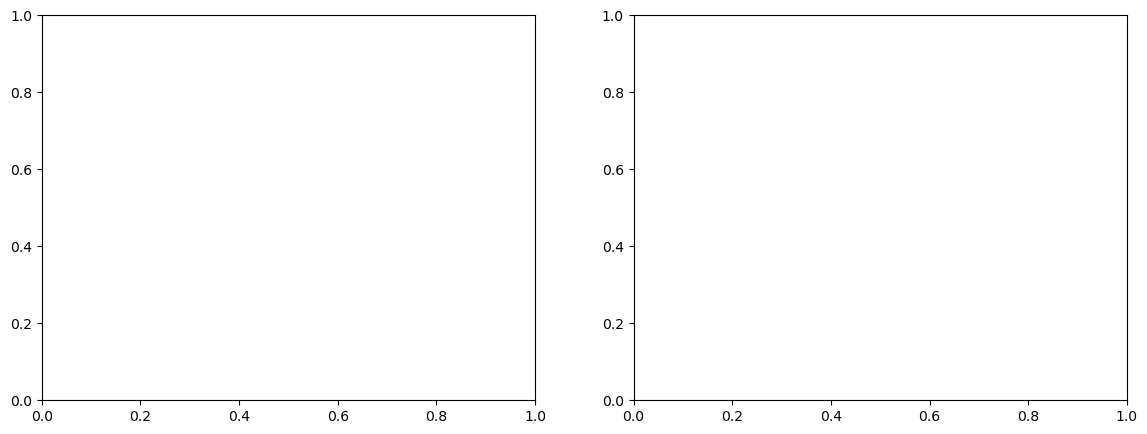

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for r in results:
    ps   = r['patch_size']
    log  = r['epoch_log']
    eps  = [e['epoch']   for e in log]
    f2s  = [e['val_f2']  for e in log]
    accs = [e['val_acc'] for e in log]
    axes[0].plot(eps, f2s,  marker='o', label=f"ps={ps}")
    axes[1].plot(eps, accs, marker='o', label=f"ps={ps}")

for ax, title in zip(axes, ['Validation F2-Score', 'Validation Accuracy']):
    ax.set_xlabel('Epoch')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(f"{MODEL_ARCH} — Patch Size Comparison (20× model)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'learning_curves.png', dpi=150)
plt.show()
print("Saved to", SAVE_DIR / 'learning_curves.png')

## Cell 11 — (Optional) Full Run on Best Patch Size  
Once you've identified the winning patch size above, run this cell to train
on the **complete** (non-subsampled) dataset for more epochs.

In [ ]:
# ── Set these after reviewing Cell 9 ─────────────────────────────────────────
# best_arch and best_ps are automatically set from Cell 9
FULL_TRAIN_EPOCHS = 15
FULL_BATCH_SIZE   = 16

print(f"Full training with arch={best_arch}, patch_size={best_ps}, {FULL_TRAIN_EPOCHS} epochs")

train_tf_full, val_tf_full = make_transforms(best_ps)

full_train_ds = MFHistologyDataset(
    train_rows_10, patch_size=best_ps,
    mode='train', transform=train_tf_full,
    max_patches_per_image=MAX_PATCHES,
)
full_val_ds = MFHistologyDataset(
    val_rows_10, patch_size=best_ps,
    mode='val', transform=val_tf_full,
    max_patches_per_image=MAX_PATCHES,
)
full_test_ds = MFHistologyDataset(
    test_rows_10, patch_size=best_ps,
    mode='test', transform=val_tf_full,
    max_patches_per_image=MAX_PATCHES,
)

print(f"  Full train patches : {len(full_train_ds)}")
print(f"  Full val patches   : {len(full_val_ds)}")
print(f"  Full test patches  : {len(full_test_ds)}")

full_train_loader = DataLoader(
    full_train_ds, batch_size=FULL_BATCH_SIZE,
    shuffle=True, num_workers=0, pin_memory=True,
)
full_val_loader = DataLoader(
    full_val_ds, batch_size=FULL_BATCH_SIZE,
    shuffle=False, num_workers=0, pin_memory=True,
)
full_test_loader = DataLoader(
    full_test_ds, batch_size=FULL_BATCH_SIZE,
    shuffle=False, num_workers=0, pin_memory=True,
)

full_model     = create_model(arch=best_arch).to(DEVICE)  # ← use best architecture
full_weights   = get_class_weights(full_train_ds, DEVICE)
full_criterion = nn.CrossEntropyLoss(weight=full_weights)
full_optimizer = optim.AdamW(full_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
full_scaler    = torch.amp.GradScaler('cuda')

best_f2_full = 0.0

for epoch in range(FULL_TRAIN_EPOCHS):
    t0 = time.time()
    tr_loss, tr_acc           = train_one_epoch_accum(full_model, full_train_loader,
                                                 full_optimizer, full_criterion, full_scaler)
    val_loss, val_acc, val_f2 = validate(full_model, full_val_loader, full_criterion)
    elapsed = time.time() - t0

    marker = ''
    if val_f2 > best_f2_full:
        best_f2_full = val_f2
        save_name    = SAVE_DIR / f"{best_arch}_ps{best_ps}_full_best.pth"  # ← use best arch
        torch.save(full_model.state_dict(), save_name)
        marker = '  ✓ saved'

    print(
        f"Epoch {epoch+1:>2}/{FULL_TRAIN_EPOCHS}  "
        f"tr_acc={tr_acc:.4f}  "
        f"val_acc={val_acc:.4f}  val_f2={val_f2:.4f}  "
        f"{elapsed:.1f}s{marker}"
    )

# ── Test set evaluation ───────────────────────────────────────────────────────
full_model.load_state_dict(torch.load(save_name, map_location=DEVICE))
_, test_acc, test_f2 = validate(full_model, full_test_loader, full_criterion)

print("\n" + "="*50)
print(f"TEST RESULTS  (arch={best_arch}, patch_size={best_ps})")
print(f"  Accuracy : {test_acc:.4f}")
print(f"  F2-Score : {test_f2:.4f}")
print("="*50)

# Save JSON summary
with open(SAVE_DIR / 'full_run_results.json', 'w') as fh:
    json.dump(dict(
        model=best_arch, patch_size=best_ps,  # ← use best arch as string
        test_acc=float(test_acc), test_f2=float(test_f2),
    ), fh, indent=2)
print(f"Saved to {SAVE_DIR / 'full_run_results.json'}")